In [2]:
# ============================================================
#   CORRECCIÓN Y DETREND UNIFICADO (GDHY 1981–2016)
#   Soluciona 'coordinate time not present in all datasets'
# ============================================================

import xarray as xr
import numpy as np
import os
from scipy.signal import detrend

BASE_DIR = r"C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128"
OUT_DIR  = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend"
os.makedirs(OUT_DIR, exist_ok=True)

CULTIVOS = ["maize", "rice", "soybean", "wheat"]

# --- función robusta ---
def procesar_cultivo(cultivo):
    print(f"\n🌾 Procesando {cultivo.upper()}...")
    path_cultivo = os.path.join(BASE_DIR, cultivo)
    files = sorted([os.path.join(path_cultivo, f) for f in os.listdir(path_cultivo) if f.endswith(".nc") or f.endswith(".nc4")])

    if not files:
        print(f"⚠️ No hay archivos NetCDF en {path_cultivo}")
        return

    yearly_datasets = []
    for f in files:
        try:
            year = int("".join([c for c in os.path.basename(f) if c.isdigit()])[:4])  # extrae el año del nombre
            ds = xr.open_dataset(f)

            # Detectar variable de rendimiento
            var_name = [v for v in ds.data_vars if "yield" in v.lower() or "var" in v.lower()]
            var_name = var_name[0] if var_name else list(ds.data_vars)[0]

            da = ds[var_name]
            # Si no existe 'time', se agrega
            if "time" not in da.coords:
                da = da.expand_dims(time=[year])
            else:
                da = da.assign_coords(time=[year])

            yearly_datasets.append(da)
        except Exception as e:
            print(f"⚠️ Error con {f}: {e}")

    if not yearly_datasets:
        print(f"⚠️ No se pudieron abrir archivos de {cultivo}.")
        return

    print(f"📦 Concatenando {len(yearly_datasets)} años...")
    da_all = xr.concat(yearly_datasets, dim="time").sortby("time")

    # Aplicar detrend temporal
    print("📉 Aplicando detrend temporal...")
    def detrend_func(x):
        mask = np.isfinite(x)
        if mask.sum() < 5:
            return np.full_like(x, np.nan)
        x_det = detrend(x[mask])
        out = np.full_like(x, np.nan)
        out[mask] = x_det
        return out

    da_detr = xr.apply_ufunc(
        detrend_func,
        da_all,
        input_core_dims=[["time"]],
        output_core_dims=[["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    da_detr.name = "yield_detrended"
    da_detr.attrs["description"] = f"Rendimiento detrendido para {cultivo} (1981–2016)"
    da_detr.attrs["source"] = "GDHY v1.3 (Paola A. Ruiz Franco, 2025)"

    out_file = os.path.join(OUT_DIR, f"{cultivo}_yield_1981_2016_DETREND_clean.nc")
    da_detr.to_netcdf(out_file, encoding={"yield_detrended": {"zlib": True, "complevel": 4}})

    print(f"✅ Guardado: {out_file}")
    print(f"📅 Años en el archivo final: {da_detr.time.values[0]} → {da_detr.time.values[-1]}")

# --- ejecutar todos ---
for cultivo in CULTIVOS:
    procesar_cultivo(cultivo)

print("\n🎯 Archivos corregidos, concatenados y detrendidos correctamente.")



🌾 Procesando MAIZE...
⚠️ Error con C:\Users\paola\Tesis\01_Data\CEREALS\gdhy_v1.2_v1.3_20190128\maize\yield_detrended_1981_2016.nc: conflicting sizes for dimension 'time': length 36 on the data but length 1 on coordinate 'time'
📦 Concatenando 36 años...
📉 Aplicando detrend temporal...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc
📅 Años en el archivo final: 1981 → 2016

🌾 Procesando RICE...
📦 Concatenando 36 años...
📉 Aplicando detrend temporal...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND_clean.nc
📅 Años en el archivo final: 1981 → 2016

🌾 Procesando SOYBEAN...
📦 Concatenando 36 años...
📉 Aplicando detrend temporal...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND_clean.nc
📅 Años en el archivo final: 1981 → 2016

🌾 Procesando WHEAT...
📦 Concatenando 36 años...
📉 Aplicando detrend temporal...
✅ Guardado: C:\Users\paola\Tesis\02_Procesados\GDHY

In [3]:
import xarray as xr
for c in ["maize", "rice", "soybean", "wheat"]:
    path = rf"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\{c}_yield_1981_2016_DETREND_clean.nc"
    ds = xr.open_dataset(path)
    print(f"{c.upper():<8} {ds['yield_detrended'].time.values[0]} → {ds['yield_detrended'].time.values[-1]}")


MAIZE    1981 → 2016
RICE     1981 → 2016
SOYBEAN  1981 → 2016
WHEAT    1981 → 2016


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os

# =========================
#  RUTAS DE ARCHIVOS
# =========================
files = {
    "soybean": r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND_clean.nc",
    "rice":    r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND_clean.nc",
    "wheat":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND_clean.nc",
    "maize":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc",
}

# =========================
#  FUNCIÓN DE RESUMEN
# =========================
def summarize_yield_nc(name, path):
    print("\n" + "="*70)
    print(f"📌 Cultivo: {name.upper()}")
    print("="*70)

    ds = xr.open_dataset(path)
    var_name = list(ds.data_vars)[0]   # el nombre de la variable (ej: 'var')
    da = ds[var_name]

    print("\n📂 Información del dataset")
    print(ds)

    # Dimensiones
    nlat = ds.dims["lat"]
    nlon = ds.dims["lon"]
    nt   = ds.dims["time"]

    total_pixels = nlat * nlon

    # Conteo de píxeles válidos (al menos un valor no-NaN en el tiempo)
    da_2d = da.isel(time=0).drop_vars("time", errors="ignore")
    mask_valid = ~np.isnan(da_2d)
    valid_pixels = mask_valid.sum().item()

    # Estadísticas de los valores de rendimiento
    vals = da.values.flatten()
    vals = vals[np.isfinite(vals)]

    stats = {
        "count": len(vals),
        "min":   float(np.min(vals)),
        "max":   float(np.max(vals)),
        "mean":  float(np.mean(vals)),
        "std":   float(np.std(vals)),
        "p25":   float(np.percentile(vals, 25)),
        "p50":   float(np.percentile(vals, 50)),
        "p75":   float(np.percentile(vals, 75)),
    }

    print("\n📊 Dimensiones")
    print(f"Lat: {nlat}, Lon: {nlon}, Tiempo: {nt}")
    print(f"Total de píxeles: {total_pixels:,}")
    print(f"Píxeles con rendimiento (no-NaN): {valid_pixels:,}")

    print("\n📈 Estadísticas de rendimiento (todos los años × todos los píxeles)")
    for k, v in stats.items():
        print(f"{k:>6}: {v:.6e}")

    # devolver stats si luego quieres guardarlo
    return {
        "cultivo": name,
        "total_pixeles": total_pixels,
        "pixeles_validos": valid_pixels,
        **stats
    }


# =========================
#   PROCESAR LOS 4 ARCHIVOS
# =========================
results = []
for name, path in files.items():
    results.append(summarize_yield_nc(name, path))

# Si quieres un dataframe resumen:
df = pd.DataFrame(results)
print("\n\n📘 RESUMEN FINAL")
print(df)



📌 Cultivo: SOYBEAN

📂 Información del dataset
<xarray.Dataset> Size: 37MB
Dimensions:  (lon: 720, lat: 360, time: 36)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 288B 1981-01-01 1982-01-01 ... 2016-01-01
Data variables:
    var      (lat, lon, time) float32 37MB ...

📊 Dimensiones
Lat: 360, Lon: 720, Tiempo: 36
Total de píxeles: 259,200
Píxeles con rendimiento (no-NaN): 2,393

📈 Estadísticas de rendimiento (todos los años × todos los píxeles)
 count: 2.125640e+05
   min: -2.897813e+00
   max: 6.288094e+00
  mean: 2.689113e-10
   std: 2.916179e-01
   p25: -1.515754e-01
   p50: 2.110573e-04
   p75: 1.509190e-01

📌 Cultivo: RICE

📂 Información del dataset
<xarray.Dataset> Size: 37MB
Dimensions:  (lon: 720, lat: 360, time: 36)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat   

C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlat = ds.dims["lat"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlon = ds.dims["lon"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt   = d


📊 Dimensiones
Lat: 360, Lon: 720, Tiempo: 36
Total de píxeles: 259,200
Píxeles con rendimiento (no-NaN): 3,568

📈 Estadísticas de rendimiento (todos los años × todos los píxeles)
 count: 3.288500e+05
   min: -1.163881e+01
   max: 1.837627e+01
  mean: 5.379552e-09
   std: 6.583233e-01
   p25: -2.600742e-01
   p50: -6.335018e-03
   p75: 2.497428e-01

📌 Cultivo: WHEAT

📂 Información del dataset
<xarray.Dataset> Size: 37MB
Dimensions:  (lon: 720, lat: 360, time: 36)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 288B 1981-01-01 1982-01-01 ... 2016-01-01
Data variables:
    var      (lat, lon, time) float32 37MB ...


C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlat = ds.dims["lat"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlon = ds.dims["lon"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt   = d


📊 Dimensiones
Lat: 360, Lon: 720, Tiempo: 36
Total de píxeles: 259,200
Píxeles con rendimiento (no-NaN): 2,346

📈 Estadísticas de rendimiento (todos los años × todos los píxeles)
 count: 4.329140e+05
   min: -1.424241e+01
   max: 1.240455e+01
  mean: 9.789220e-09
   std: 7.443135e-01
   p25: -2.500446e-01
   p50: -5.346591e-03
   p75: 2.558145e-01

📌 Cultivo: MAIZE

📂 Información del dataset
<xarray.Dataset> Size: 37MB
Dimensions:  (lon: 720, lat: 360, time: 36)
Coordinates:
  * lon      (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 288B 1981-01-01 1982-01-01 ... 2016-01-01
Data variables:
    var      (lat, lon, time) float32 37MB ...


C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlat = ds.dims["lat"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlon = ds.dims["lon"]
C:\Users\paola\AppData\Local\Temp\ipykernel_41980\2870759847.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nt   = d


📊 Dimensiones
Lat: 360, Lon: 720, Tiempo: 36
Total de píxeles: 259,200
Píxeles con rendimiento (no-NaN): 5,228

📈 Estadísticas de rendimiento (todos los años × todos los píxeles)
 count: 5.168200e+05
   min: -1.201269e+01
   max: 2.275498e+01
  mean: 1.418554e-09
   std: 6.900980e-01
   p25: -2.531779e-01
   p50: -7.071794e-03
   p75: 2.457250e-01


📘 RESUMEN FINAL
   cultivo  total_pixeles  pixeles_validos   count        min        max  \
0  soybean         259200             2393  212564  -2.897813   6.288094   
1     rice         259200             3568  328850 -11.638809  18.376268   
2    wheat         259200             2346  432914 -14.242414  12.404553   
3    maize         259200             5228  516820 -12.012688  22.754976   

           mean       std       p25       p50       p75  
0  2.689113e-10  0.291618 -0.151575  0.000211  0.150919  
1  5.379552e-09  0.658323 -0.260074 -0.006335  0.249743  
2  9.789220e-09  0.744313 -0.250045 -0.005347  0.255815  
3  1.418554e-09  0

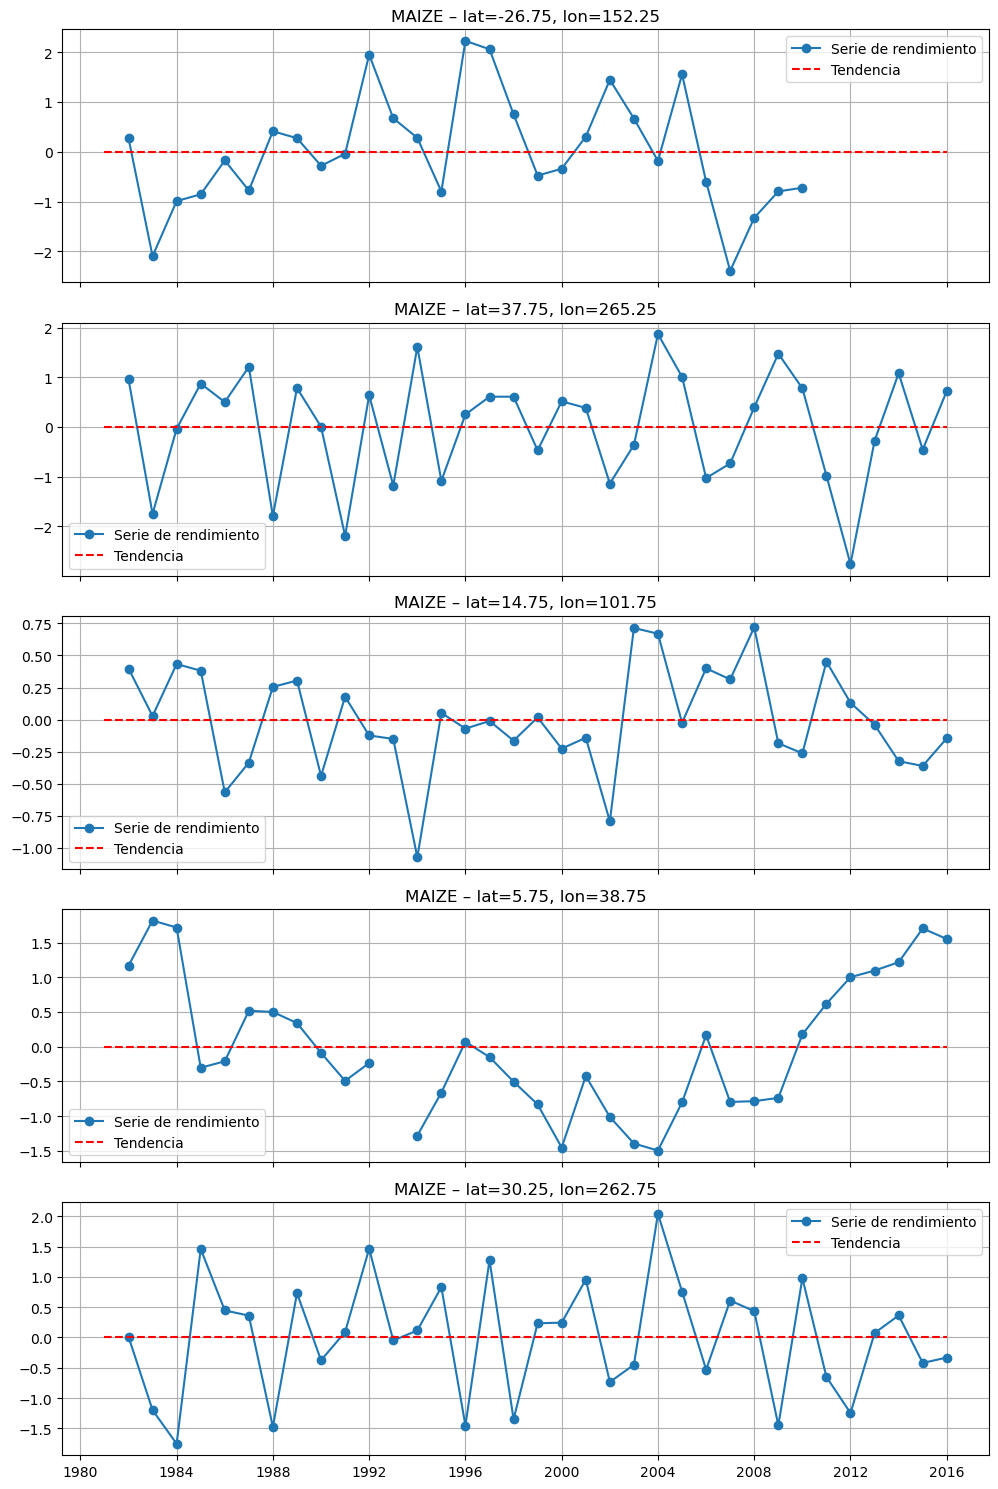

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def plot_point_trends(ncfile, cultivo, npoints=5):
    
    # === ABRIR ARCHIVO ===
    ds = xr.open_dataset(ncfile)
    varname = list(ds.data_vars)[0]
    da = ds[varname]

    # === 1. APILAR LAT/LON A 1D ===
    da_stacked = da.stack(pixel=("lat", "lon"))

    # === 2. MÁSCARA DE PIXELES CON AL MENOS UN DATO ===
    mask_valid = xr.ufuncs.isfinite(da_stacked).any(dim="time")

    # Filtrar solo píxeles que sí tienen rendimiento
    valid_pixels = da_stacked[:, mask_valid]

    # === 3. Seleccionar píxeles aleatorios ===
    total_valid = valid_pixels.pixel.size
    if total_valid < npoints:
        npoints = total_valid

    chosen_pixels = np.random.choice(valid_pixels.pixel.values, size=npoints, replace=False)

    # === 4. Graficar ===
    fig, axes = plt.subplots(npoints, 1, figsize=(10, 3*npoints), sharex=True)
    if npoints == 1:
        axes = [axes]

    time_idx = np.arange(da.time.size)

    for ax, pix in zip(axes, chosen_pixels):

        # serie de tiempo del pixel
        series = valid_pixels.sel(pixel=pix).values

        # tendencia
        mask = np.isfinite(series)
        reg = LinearRegression().fit(time_idx[mask].reshape(-1, 1), series[mask])
        trend = reg.predict(time_idx.reshape(-1, 1))

        # obtener coordenadas reales
        lat, lon = valid_pixels['pixel'].sel(pixel=pix).item()

        ax.plot(ds.time.values, series, 'o-', label="Serie de rendimiento")
        ax.plot(ds.time.values, trend, 'r--', label="Tendencia")

        ax.set_title(f"{cultivo.upper()} – lat={lat:.2f}, lon={lon:.2f}")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


# === EJEMPLO PARA MAÍZ ===
plot_point_trends(
    r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc",
    "maize",
    npoints=5
)


In [8]:
import xarray as xr
import numpy as np

# ===== archivo de WHEAT =====
path_wheat = r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND_clean.nc"
ds = xr.open_dataset(path_wheat)

var = list(ds.data_vars)[0]
da = ds[var]

# ============================
# BOUNDING BOX DE MOZAMBIQUE
# ============================
lat_min, lat_max = -26.9, -10.4
lon_min, lon_max = 30, 41   # ya en formato 0–360

# 1) Filtrar por bbox
subset = da.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# 2) Encontrar píxeles con datos de trigo
mask = subset.isel(time=0).notnull()

lat_idx, lon_idx = np.where(mask.values)

if len(lat_idx) == 0:
    print("❌ No se encontraron píxeles de trigo dentro de Mozambique.")
else:
    # Seleccionar un píxel representativo
    ilat = lat_idx[0]
    ilon = lon_idx[0]
    
    lat_sel = float(subset.lat.values[ilat])
    lon_sel = float(subset.lon.values[ilon])
    
    print("✅ Píxel encontrado en Mozambique:")
    print(f"Latitud: {lat_sel}")
    print(f"Longitud: {lon_sel}")

    # Extraer la serie
    wheat_series = subset[:, ilat, ilon].values

    print("\n📈 Serie de tiempo lista para correlación:")
    print(wheat_series)


✅ Píxel encontrado en Mozambique:
Latitud: -26.75
Longitud: 30.25

📈 Serie de tiempo lista para correlación:
[ 0.2943017   0.3535749   1.492461    0.2273284   0.0609432          nan
         nan         nan         nan  2.227142   -5.792143           nan
 -0.73596084         nan         nan         nan -0.9218475          nan
 -0.92130226         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan]


In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import os

# ===========================
# ARCHIVOS DETREND
# ===========================
files = {
    "soybean": r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND_clean.nc",
    "rice":    r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND_clean.nc",
    "wheat":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND_clean.nc",
    "maize":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc",
}

OUT = r"C:\Users\paola\Tesis\03_Resultados\Puntos\Validacion"
os.makedirs(OUT, exist_ok=True)

# ===========================
# FUNCIÓN PRINCIPAL
# ===========================
def analizar_pixeles(ncfile, cultivo):

    print(f"\nAnalizando {cultivo} ...")

    ds = xr.open_dataset(ncfile)
    var = list(ds.data_vars)[0]
    da = ds[var]

    # Apilar a una dimensión: pixel = lat/lon
    da_stacked = da.stack(pixel=("lat", "lon"))

    # Lista para almacenar resultados
    registros = []

    for pix in da_stacked.pixel.values:
        serie = da_stacked.sel(pixel=pix).values
        
        # Años válidos (no NaN)
        valid_mask = np.isfinite(serie)
        valid_years = valid_mask.sum()
        
        if valid_years == 0:
            continue  # no tiene datos de rendimiento
        
        lat = float(da_stacked.pixel.sel(pixel=pix)["lat"])
        lon = float(da_stacked.pixel.sel(pixel=pix)["lon"])

        vals = serie[valid_mask]
        
        registro = {
            "lat": lat,
            "lon": lon,
            "años_validos": valid_years,
            "porcentaje_valido": valid_years / len(serie),
            "min": np.min(vals),
            "max": np.max(vals),
            "std": np.std(vals),
        }

        registros.append(registro)

    # Convertir a tabla
    df = pd.DataFrame(registros)
    
    # Guardar
    outpath = os.path.join(OUT, f"{cultivo}_pixeles_validos.csv")
    df.to_csv(outpath, index=False)
    
    print(f"✔ Archivo generado: {outpath}")
    print(df.describe())
    return df


# ===========================
# PROCESAR TODOS LOS CULTIVOS
# ===========================
all_results = {}
for cultivo, path in files.items():
    df = analizar_pixeles(path, cultivo)
    all_results[cultivo] = df



Analizando soybean ...
✔ Archivo generado: C:\Users\paola\Tesis\03_Resultados\Puntos\Validacion\soybean_pixeles_validos.csv
               lat          lon  años_validos  porcentaje_valido          min  \
count  6122.000000  6122.000000   6122.000000        6122.000000  6122.000000   
mean     15.485544   193.319912     34.721333           0.964481    -0.583091   
std      28.411700   102.874983      1.940993           0.053916     0.299676   
min     -38.750000     3.750000     13.000000           0.361111    -2.897813   
25%     -16.750000   107.750000     35.000000           0.972222    -0.684796   
50%      27.250000   259.750000     35.000000           0.972222    -0.518510   
75%      38.750000   294.750000     36.000000           1.000000    -0.403092   
max      53.250000   316.750000     36.000000           1.000000    -0.031006   

               max          std  
count  6122.000000  6122.000000  
mean      0.592477     0.262616  
std       0.382874     0.131235  
min      


   Procesando cultivo: soybean

=== RANGOS POR CLUSTER ===
   cluster  min  max
0      0.0   13   28
1      1.0   29   35
2      2.0   32   35
3      3.0   36   36


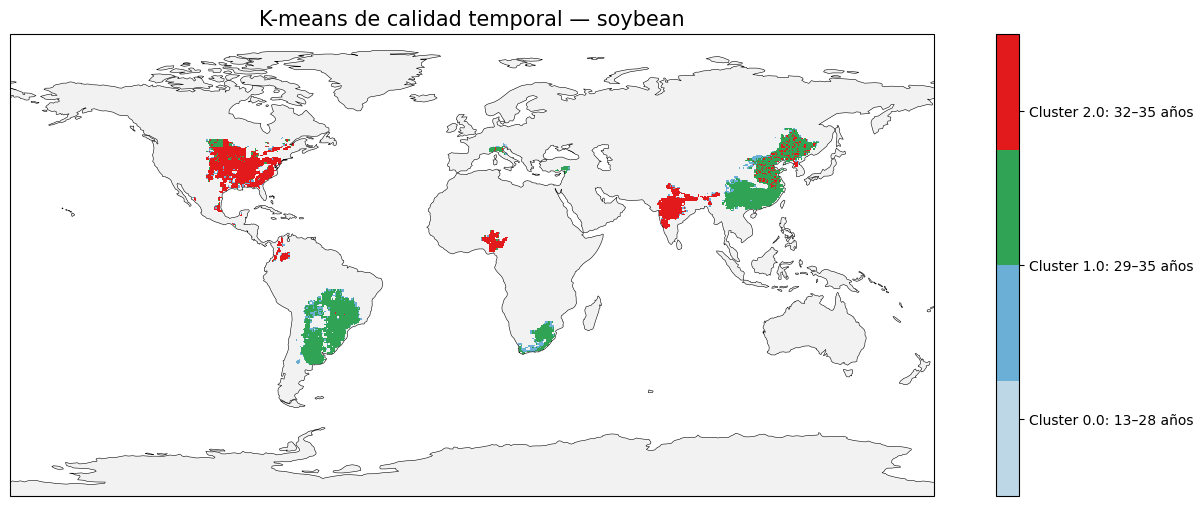


   Procesando cultivo: rice

=== RANGOS POR CLUSTER ===
   cluster  min  max
0      0.0    5   18
1      1.0   19   33
2      2.0   25   35
3      3.0   34   36


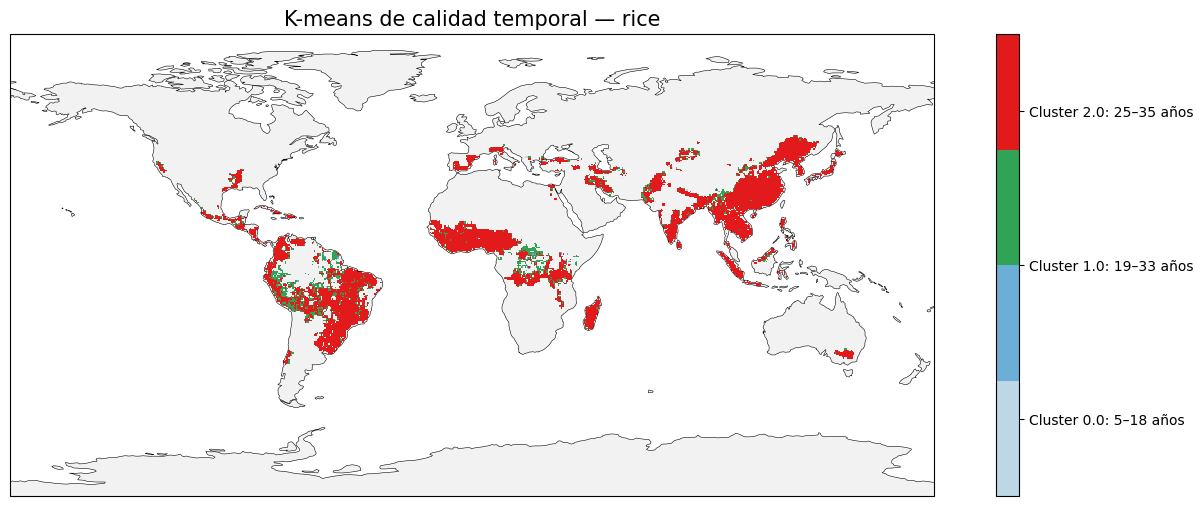


   Procesando cultivo: wheat

=== RANGOS POR CLUSTER ===
   cluster  min  max
0      0.0    5   26
1      1.0   24   32
2      2.0   28   35
3      3.0   33   36


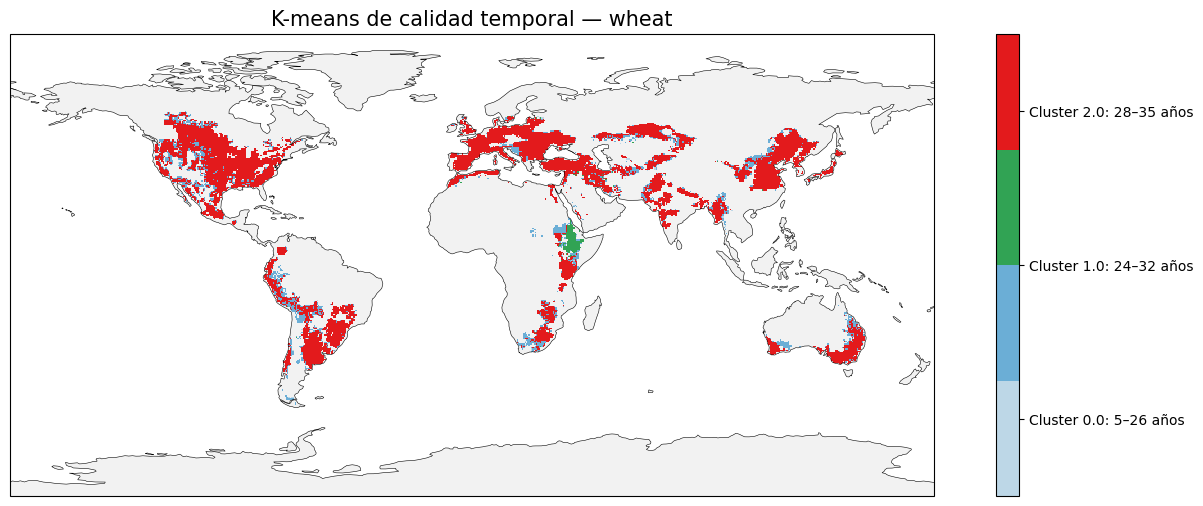


   Procesando cultivo: maize

=== RANGOS POR CLUSTER ===
   cluster  min  max
0      0.0    5   25
1      1.0   24   31
2      2.0   25   35
3      3.0   34   36


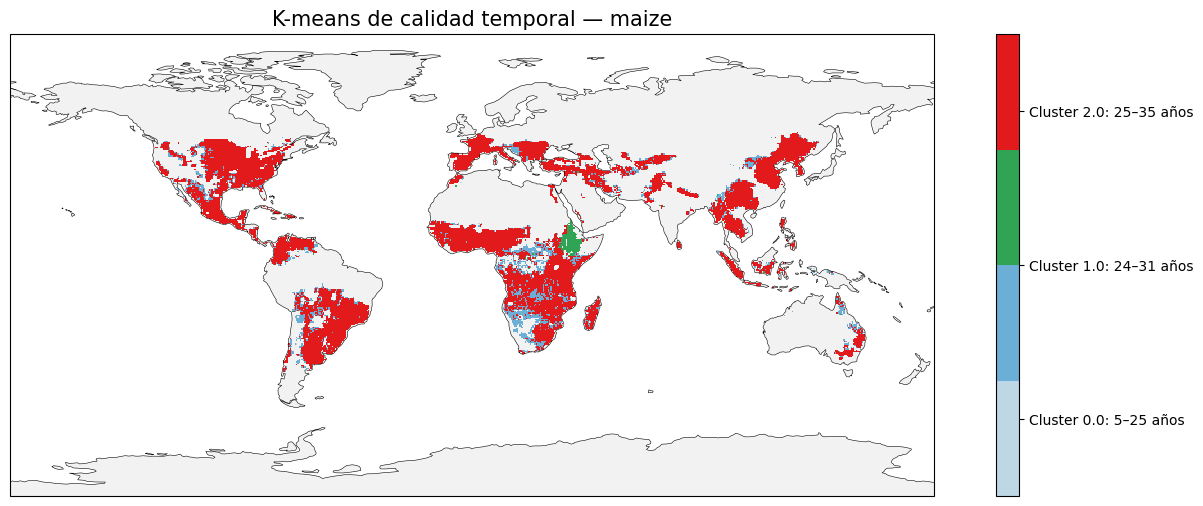



🎉 PROCESO COMPLETADO PARA LOS 4 CULTIVOS
Mapas y CSV guardados en: C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad


In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

# ========================================================
# FUNCIONES AUXILIARES
# ========================================================

def longest_consecutive_run(arr):
    """Calcula la mayor cantidad de años consecutivos válidos."""
    run = 0
    best = 0
    for v in arr:
        if np.isfinite(v):
            run += 1
            best = max(best, run)
        else:
            run = 0
    return best


# ========================================================
# FUNCIÓN PRINCIPAL K-MEANS CALIDAD TEMPORAL
# ========================================================

def kmeans_calidad_temporal(ncfile, cultivo, k=4, out_dir=None):

    print(f"\n====================================================")
    print(f"   Procesando cultivo: {cultivo}")
    print(f"====================================================")

    ds = xr.open_dataset(ncfile)
    da = ds[list(ds.data_vars)[0]]
    
    da_stacked = da.stack(pixel=("lat","lon"))

    rows = []

    # ====================================================
    # Construcción tabla de calidad por píxel
    # ====================================================
    for p in da_stacked.pixel:
        serie = da_stacked.sel(pixel=p).values
        valid = np.isfinite(serie)
        años_validos = valid.sum()

        lat_p = float(p["lat"])
        lon_p = float(p["lon"])

        if años_validos == 0:
            rows.append([lat_p, lon_p, 0, 36, 0])
            continue

        gap = 36 - años_validos
        long_run = longest_consecutive_run(serie)

        rows.append([lat_p, lon_p, años_validos, gap, long_run])

    df = pd.DataFrame(rows, columns=["lat","lon","años_validos","gap","longest_run"])

    # Solo píxeles agrícolas reales (>=1 año válido)
    df_agri = df[df["años_validos"] > 0].copy()

    # ====================================================
    # K-means con 3 variables
    # ====================================================
    X = df_agri[["años_validos","gap","longest_run"]].values
    X_scaled = StandardScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42)
    df_agri["cluster_raw"] = kmeans.fit_predict(X_scaled)

    # Mezclar con píxeles sin datos
    df = df.merge(df_agri[["lat","lon","cluster_raw"]],
                  on=["lat","lon"], how="left")

    # ====================================================
    # ORDENAR CLÚSTERES POR CALIDAD REAL
    # ====================================================
    cluster_stats = df_agri.groupby("cluster_raw")["años_validos"].mean().sort_values()

    # Esto asegura que cluster 0 = malo, cluster k-1 = excelente
    ordered_clusters = {old:i for i,old in enumerate(cluster_stats.index)}

    df["cluster"] = df["cluster_raw"].map(ordered_clusters)

    # ====================================================
    # RANGOS REALES POR CLÚSTER
    # ====================================================
    rangos = df.groupby("cluster")["años_validos"].agg(["min","max"]).reset_index()

    print("\n=== RANGOS POR CLUSTER ===")
    print(rangos)

    # ====================================================
    # COLORMAP CORRECTO (0 malo —> 3 excelente)
    # ====================================================
    colors = {
        0: "#bdd7e7",  # malo       (pocos años válidos)
        1: "#6baed6",  # medio
        2: "#31a354",  # bueno
        3: "#e31a1c"   # excelente  (máximo de años válidos)
    }

    cmap = mcolors.ListedColormap([colors[i] for i in sorted(df["cluster"].dropna().unique())])

    # ====================================================
    # MAPA
    # ====================================================
    plt.figure(figsize=(16,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)

    mat = df.pivot(index="lat", columns="lon", values="cluster")

    img = plt.pcolormesh(mat.columns, mat.index, mat.values,
                         cmap=cmap, shading="nearest")

    # LEYENDA EXACTA
    labels = []
    for _, row in rangos.iterrows():
        labels.append(
            f"Cluster {row['cluster']}: {int(row['min'])}–{int(row['max'])} años"
        )

    cbar = plt.colorbar(img, ticks=np.arange(0.5, k, 1))
    cbar.ax.set_yticklabels(labels)

    ax.set_title(f"K-means de calidad temporal — {cultivo}", fontsize=15)

    # Guardar
    if out_dir:
        plt.savefig(os.path.join(out_dir, f"{cultivo}_kmeans_calidad.png"),
                    dpi=300, bbox_inches="tight")

    plt.show()

    # Guardar CSV
    if out_dir:
        df.to_csv(os.path.join(out_dir, f"{cultivo}_kmeans_clusters.csv"),
                  index=False)

    return df, rangos



# ========================================================
# EJECUTAR PARA TODOS LOS CULTIVOS
# ========================================================

files = {
    "soybean": r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\soybean_yield_1981_2016_DETREND_clean.nc",
    "rice":    r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\rice_yield_1981_2016_DETREND_clean.nc",
    "wheat":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\wheat_yield_1981_2016_DETREND_clean.nc",
    "maize":   r"C:\Users\paola\Tesis\02_Procesados\GDHY_detrend\maize_yield_1981_2016_DETREND_clean.nc",
}

OUTPUT = r"C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad"
os.makedirs(OUTPUT, exist_ok=True)

resultados = {}

for cultivo, path in files.items():
    df, rangos = kmeans_calidad_temporal(path, cultivo, k=4, out_dir=OUTPUT)
    resultados[cultivo] = rangos

print("\n\n🎉 PROCESO COMPLETADO PARA LOS 4 CULTIVOS")
print("Mapas y CSV guardados en:", OUTPUT)


In [20]:
import pandas as pd

df = pd.read_csv(r"C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad\maize_kmeans_clusters.csv")
df[df["cluster"] == df["cluster"].max()]


,lat,lon,años_validos,gap,longest_run,cluster_raw,cluster
70413,-41.25,286.75,34,2,33,0.0,3.0
71133,-40.75,286.75,34,2,33,0.0,3.0
71134,-40.75,287.25,34,2,33,0.0,3.0
71153,-40.75,296.75,34,2,33,0.0,3.0
71853,-40.25,286.75,34,2,33,0.0,3.0
...,...,...,...,...,...,...,...
203289,51.25,124.75,35,1,35,0.0,3.0
203290,51.25,125.25,35,1,35,0.0,3.0
203291,51.25,125.75,35,1,35,0.0,3.0
203292,51.25,126.25,35,1,35,0.0,3.0


In [21]:
import pandas as pd
import os

BASE = r"C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad"

cultivos = ["maize", "rice", "wheat", "soybean"]

for c in cultivos:
    print("\n===============================")
    print(f"REVISANDO: {c.upper()}")
    print("===============================")

    f = os.path.join(BASE, f"{c}_kmeans_clusters.csv")
    df = pd.read_csv(f)

    print("\n📌 Columnas del archivo:")
    print(df.columns)

    print("\n📌 Primeras filas:")
    print(df.head())

    print("\n📌 Valores únicos de cluster:")
    print(df["cluster"].unique())

    print("\n📌 Cantidad de puntos por cluster:")
    print(df["cluster"].value_counts().sort_index())

    # cluster más alto = “mejor”
    max_cluster = df["cluster"].max()
    df_buenos = df[df["cluster"] == max_cluster]

    print(f"\n📌 Cluster mayor (BUENO): {max_cluster}")
    print(f"Píxeles buenos: {len(df_buenos)}")

    print("\n📌 Rangos de años válidos por cluster:")
    print(df.groupby("cluster")["años_validos"].agg(["min","max","mean"]))



REVISANDO: MAIZE

📌 Columnas del archivo:
Index(['lat', 'lon', 'años_validos', 'gap', 'longest_run', 'cluster_raw',
       'cluster'],
      dtype='object')

📌 Primeras filas:
     lat   lon  años_validos  gap  longest_run  cluster_raw  cluster
0 -89.75  0.25             0   36            0          NaN      NaN
1 -89.75  0.75             0   36            0          NaN      NaN
2 -89.75  1.25             0   36            0          NaN      NaN
3 -89.75  1.75             0   36            0          NaN      NaN
4 -89.75  2.25             0   36            0          NaN      NaN

📌 Valores únicos de cluster:
[nan  3.  1.  0.  2.]

📌 Cantidad de puntos por cluster:
cluster
0.0       47
1.0     2325
2.0      302
3.0    12436
Name: count, dtype: int64

📌 Cluster mayor (BUENO): 3.0
Píxeles buenos: 12436

📌 Rangos de años válidos por cluster:
         min  max       mean
cluster                     
0.0        5   25  15.446809
1.0       24   31  29.253763
2.0       25   35  32.566225



📌 CULTIVO: MAIZE


C:\Users\paola\anaconda3\envs\geo2env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


→ Pixeles en cluster bueno: 12436
→ Umbral dinámico std: 0.1450
→ Píxeles finales útiles: 11192


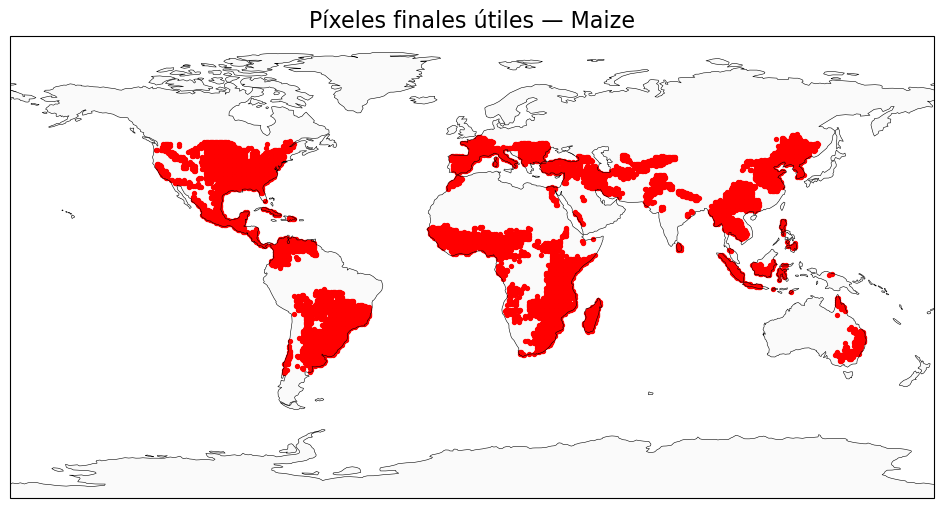


📌 CULTIVO: RICE


C:\Users\paola\anaconda3\envs\geo2env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


→ Pixeles en cluster bueno: 8141
→ Umbral dinámico std: 0.1989
→ Píxeles finales útiles: 7327


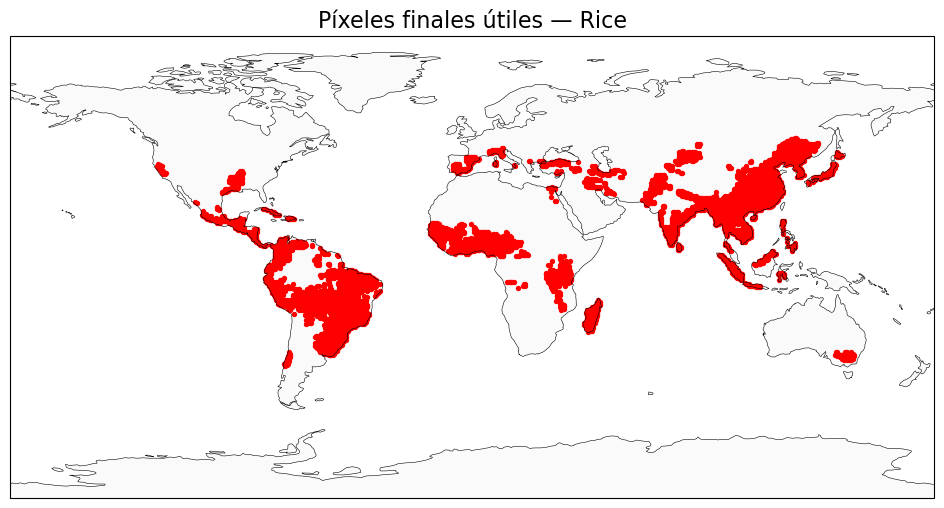


📌 CULTIVO: WHEAT


C:\Users\paola\anaconda3\envs\geo2env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


→ Pixeles en cluster bueno: 10289
→ Umbral dinámico std: 0.1929
→ Píxeles finales útiles: 9260


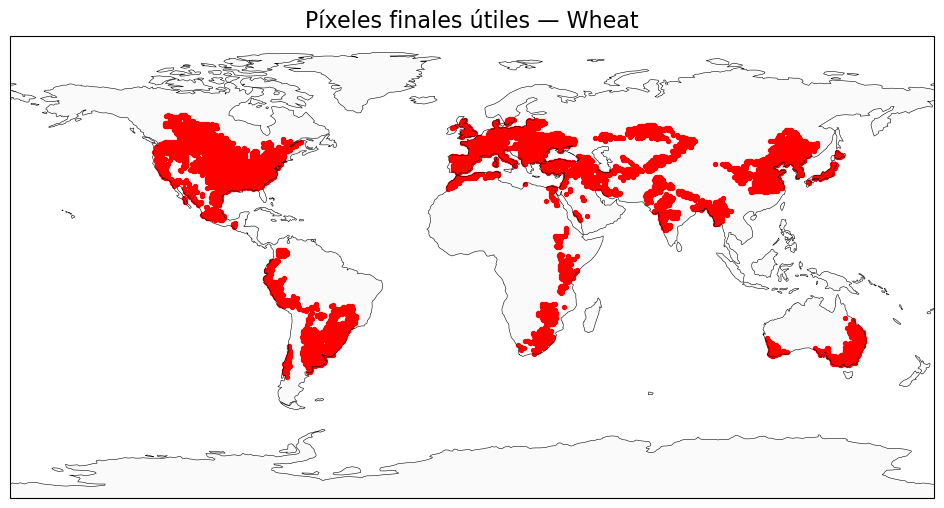


📌 CULTIVO: SOYBEAN


C:\Users\paola\anaconda3\envs\geo2env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


→ Pixeles en cluster bueno: 2266
→ Umbral dinámico std: 0.1248
→ Píxeles finales útiles: 2039


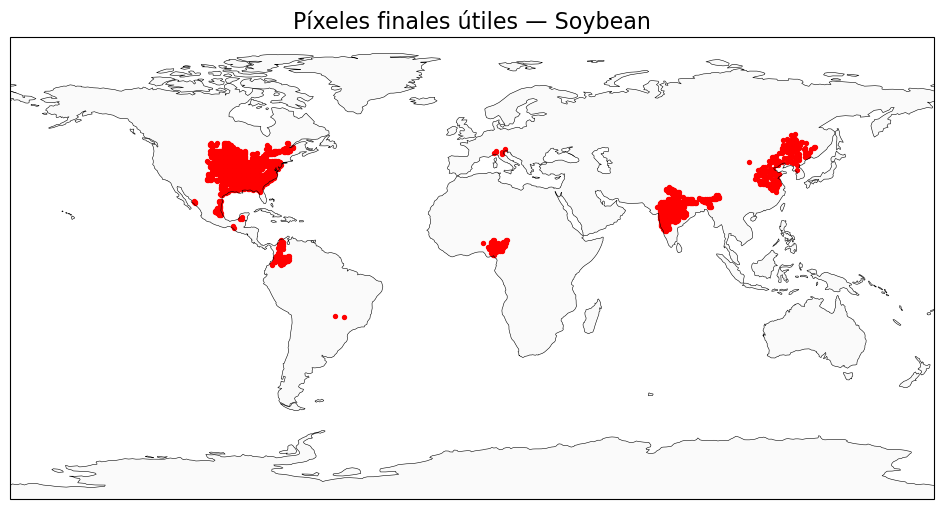


🎉 PROCESO COMPLETADO — intersección temporal + utilidad 🎉


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# ======================================================
# CONFIGURACIÓN
# ======================================================

BASE = r"C:\Users\paola\Tesis"
DIR_CLUSTERS = os.path.join(BASE, r"03_Resultados\Puntos\Kmeans_Calidad")
DIR_YIELD = os.path.join(BASE, r"02_Procesados\GDHY_detrend")
OUT = os.path.join(BASE, r"03_Resultados\Puntos\Puntos_Finales")
os.makedirs(OUT, exist_ok=True)

cultivos = ["maize", "rice", "wheat", "soybean"]


# ======================================================
# FUNCIÓN PARA CALCULAR STD POR PIXEL
# ======================================================

def calcular_std_por_pixel(ncfile, varname=None):
    ds = xr.open_dataset(ncfile)
    if varname is None:
        varname = list(ds.data_vars)[0]
    da = ds[varname]

    std_map = da.std(dim="time", skipna=True)
    return std_map


# ======================================================
# FUNCIÓN PARA GRAFICAR
# ======================================================

def graficar_puntos(df, cultivo):
    plt.figure(figsize=(14,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    ax.add_feature(cfeature.LAND, facecolor="#fafafa")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)

    ax.scatter(df["lon"], df["lat"], s=8, color="red", transform=ccrs.PlateCarree())
    ax.set_title(f"Píxeles finales útiles — {cultivo.capitalize()}", fontsize=16)

    plt.savefig(os.path.join(OUT, f"{cultivo}_puntos_finales.png"), dpi=300)
    plt.show()


# ======================================================
# BUCLE
# ======================================================

for cultivo in cultivos:
    print("\n==============================================")
    print(f"📌 CULTIVO: {cultivo.upper()}")
    print("==============================================")

    # CSV del cluster K-means
    df = pd.read_csv(os.path.join(DIR_CLUSTERS, f"{cultivo}_kmeans_clusters.csv"))

    # STD real
    std_map = calcular_std_por_pixel(os.path.join(DIR_YIELD,
                                f"{cultivo}_yield_1981_2016_DETREND_clean.nc"))
    std_df = std_map.to_dataframe(name="std").reset_index()

    # unir info
    df2 = df.merge(std_df, on=["lat","lon"], how="left")

    # ================================
    # FILTRO CLUSTER BUENO
    # ================================
    cluster_good = df2[df2["cluster"] == 3].copy()
    print(f"→ Pixeles en cluster bueno: {len(cluster_good)}")

    # ================================
    # UMBRAL DINÁMICO POR STD (10% más plano)
    # ================================
    umbral_std = cluster_good["std"].quantile(0.10)   # percentil 10

    print(f"→ Umbral dinámico std: {umbral_std:.4f}")

    df_final = cluster_good[cluster_good["std"] >= umbral_std].copy()

    print(f"→ Píxeles finales útiles: {len(df_final)}")

    # guardar
    df_final.to_csv(os.path.join(OUT,
                 f"{cultivo}_puntos_utiles_interseccion.csv"), index=False)

    # mapa
    graficar_puntos(df_final, cultivo)

print("\n🎉 PROCESO COMPLETADO — intersección temporal + utilidad 🎉")


In [1]:
import pandas as pd
import os

BASE = r"C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad"
cultivos = ["maize", "rice", "wheat", "soybean"]

for c in cultivos:
    print("\n===============================")
    print(f"DETECTANDO CLUSTER BUENO: {c.upper()}")
    print("===============================")

    f = os.path.join(BASE, f"{c}_kmeans_clusters.csv")
    df = pd.read_csv(f)

    # estadísticas por cluster
    stats = df.groupby("cluster").agg({
        "años_validos": ["mean","min","max"],
        "gap": ["mean","min","max"],
        "longest_run": ["mean","min","max"]
    })

    print("\n📊 Estadísticas por cluster:")
    print(stats)

    # RANKING
    # más años válidos = mejor (rank descendente)
    # menos gap = mejor (rank ascendente)
    # longest_run mayor = mejor (rank descendente)

    rank = pd.DataFrame()
    rank["score_años"] = stats["años_validos"]["mean"].rank(ascending=False)
    rank["score_gap"] = stats["gap"]["mean"].rank(ascending=True)
    rank["score_run"] = stats["longest_run"]["mean"].rank(ascending=False)

    # sumatoria del score
    rank["total_score"] = rank.sum(axis=1)

    print("\n📌 Score combinado:")
    print(rank)

    cluster_bueno = rank["total_score"].idxmin()

    print(f"\n🔥 CLUSTER BUENO PARA {c.upper()} = {cluster_bueno}")

    # extraer solo píxeles buenos
    df_buenos = df[df["cluster"] == cluster_bueno]

    print(f"Píxeles aptos para correlación: {len(df_buenos)}")



DETECTANDO CLUSTER BUENO: MAIZE

📊 Estadísticas por cluster:
        años_validos                gap         longest_run        
                mean min max       mean min max        mean min max
cluster                                                            
0.0        15.446809   5  25  20.553191  11  31    7.404255   2  17
1.0        29.253763  24  31   6.746237   5  12   29.209892  16  31
2.0        32.566225  25  35   3.433775   1  11   21.258278  12  23
3.0        35.239949  34  36   0.760051   0   2   35.112576  32  36

📌 Score combinado:
         score_años  score_gap  score_run  total_score
cluster                                               
0.0             4.0        4.0        4.0         12.0
1.0             3.0        3.0        2.0          8.0
2.0             2.0        2.0        3.0          7.0
3.0             1.0        1.0        1.0          3.0

🔥 CLUSTER BUENO PARA MAIZE = 3.0
Píxeles aptos para correlación: 12436

DETECTANDO CLUSTER BUENO: RICE

📊 Estad

In [5]:
import pandas as pd
import os

BASE = r"C:\Users\paola\Tesis\03_Resultados\Puntos\Kmeans_Calidad"
cultivos = ["maize", "rice", "wheat", "soybean"]

for c in cultivos:
    print("\n===============================")
    print(f"CULTIVO: {c.upper()}")
    print("===============================")

    f = os.path.join(BASE, f"{c}_kmeans_clusters.csv")
    df = pd.read_csv(f)

    # cluster con más años válidos
    stats = df.groupby("cluster")["años_validos"].mean()
    cluster_bueno = stats.idxmax()

    print(f"🔥 Cluster con MÁS AÑOS VÁLIDOS = {cluster_bueno}")

    # cuántos píxeles tiene ese cluster
    n_buenos = (df["cluster"] == cluster_bueno).sum()
    print(f"📌 Pixeles óptimos para correlación: {n_buenos}")

    # rango real de años válidos en ese cluster
    subset = df[df["cluster"] == cluster_bueno]
    print("\nRango de años válidos en ese cluster:")
    print(subset["años_validos"].describe())



CULTIVO: MAIZE
🔥 Cluster con MÁS AÑOS VÁLIDOS = 3.0
📌 Pixeles óptimos para correlación: 12436

Rango de años válidos en ese cluster:
count    12436.000000
mean        35.239949
std          0.657149
min         34.000000
25%         35.000000
50%         35.000000
75%         36.000000
max         36.000000
Name: años_validos, dtype: float64

CULTIVO: RICE
🔥 Cluster con MÁS AÑOS VÁLIDOS = 3.0
📌 Pixeles óptimos para correlación: 8141

Rango de años válidos en ese cluster:
count    8141.00000
mean       35.29898
std         0.62800
min        34.00000
25%        35.00000
50%        35.00000
75%        36.00000
max        36.00000
Name: años_validos, dtype: float64

CULTIVO: WHEAT
🔥 Cluster con MÁS AÑOS VÁLIDOS = 3.0
📌 Pixeles óptimos para correlación: 10289

Rango de años válidos en ese cluster:
count    10289.000000
mean        35.069978
std          0.509018
min         33.000000
25%         35.000000
50%         35.000000
75%         35.000000
max         36.000000
Name: años_validos